# Introduction

This notebook contains tiny neural networks. One is a single neuron with a step function, the rest are neural networks with 2 hidden layers and an output neuron. Import the dependancies under.

You can 'hide' these markdown blocks by clicking the down arrow to the left. It makes the document eaiser to navigate. You can use the headlines to hide and extend only the blocks you need.

In [28]:
import matplotlib.pyplot as plt
import random
import math


## single neuron

the code blocks under here are for the single neuron exercise in my youtube tutorial. Names here are different from the video, but it works the same

In [29]:
data = [
    (0, 0, 0),
    (1, 0, 1),
    (0, 1, 1),
    (1, 1, 1),
]

In [30]:
w1 = 0.00 #weight1
w2 = 0.00 #weight2
b = 0.00 #bias
lr = 0.1 #learning rate


In [31]:
def step(z):
    return 1 if z >= 0 else 0

def neuron(input1, input2):
    return step(input1 * w1 + input2 * w2 + b)

for i in range(5):
    print("\033[1;4;41mROUND:", i + 1, "\033[0m")
    for input1, input2, target in data:
        prediction = neuron(input1, input2)
        error = prediction - target
        
        w1 -= lr * error * input1
        w2 -= lr * error * input2
        b -= lr * error
    
        print(f'inputs: {input1}, {input2}, correct prediction: {target}, given prediction: {prediction},\nerror: {error}, w1: {w1}, w2: {w2}, b: {b} \n')

ROUND: 1 
inputs: 0, 0, correct prediction: 0, given prediction: 1,
error: 1, w1: 0.0, w2: 0.0, b: -0.1 

inputs: 1, 0, correct prediction: 1, given prediction: 0,
error: -1, w1: 0.1, w2: 0.0, b: 0.0 

inputs: 0, 1, correct prediction: 1, given prediction: 1,
error: 0, w1: 0.1, w2: 0.0, b: 0.0 

inputs: 1, 1, correct prediction: 1, given prediction: 1,
error: 0, w1: 0.1, w2: 0.0, b: 0.0 

ROUND: 2 
inputs: 0, 0, correct prediction: 0, given prediction: 1,
error: 1, w1: 0.1, w2: 0.0, b: -0.1 

inputs: 1, 0, correct prediction: 1, given prediction: 1,
error: 0, w1: 0.1, w2: 0.0, b: -0.1 

inputs: 0, 1, correct prediction: 1, given prediction: 0,
error: -1, w1: 0.1, w2: 0.1, b: 0.0 

inputs: 1, 1, correct prediction: 1, given prediction: 1,
error: 0, w1: 0.1, w2: 0.1, b: 0.0 

ROUND: 3 
inputs: 0, 0, correct prediction: 0, given prediction: 1,
error: 1, w1: 0.1, w2: 0.1, b: -0.1 

inputs: 1, 0, correct prediction: 1, given prediction: 1,
error: 0, w1: 0.1, w2: 0.1, b: -0.1 

inputs: 0, 1,

# The hidden node networks

The blocks that are under here are for the neural network that contain an output neuron and two hidden neurons. You can change the dataset to be different logic gates. You can also add higher numbers to teach it arithmatic and other mathematical tasks.

Each block will have a different activation function (for example sigmoid) which the network uses to predict an answer, and its derivative (dsigmoid) which the weights and biases use to adjust themselves.

GENS: How many rounds to run
UNTIL: if text logging is enabled, the result of the round will be dispalyed every round until this.

EVERY: Text will be dispalyed every n round after UNTIL has passed.

### dataset and controls

In [34]:

#training data. first 2 rows are input.
#last row is output
data = [
    (0, 0, 0),
    (1, 0, 1),
    (0, 1, 1),
    (1, 1, 2),
    (3, 5, 8),
    (2, 4, 6),
    (1, 3, 4),
    (6, 5, 11),
]

#controls. Use these to test learning
control = [
    (2, 2, 4),
    (4, 4, 8),
    (6, 6, 12),

]
# roof is used to adjust score for 
# tanh and sigmoids if max output is greater than 1.
# normally tanh and Sigmoid can't go beyond 1, but these
# functions are used so that 1 corresponds to the highest
# output in data or control,
# for example when learning addition.
roof = 1 / max(y for _, _, y in data + control)
print(roof)

def tanh_roof(z):
    return -1 + z * roof * 2

def tanh_prediction(z):
    return ((z + 1)/2) / roof


0.08333333333333333


### Initialize weights and parameters

run the block below to initilaize weights, create lists and some important functions. 

He init is used for ReLU, LReLU, ELU etc. Basically any ReLU variant. Xavier for sigmoid and tanh. 

You can change what init you use in different activation function blocks. In raw output, set active to True if you want the output to be displayed in text when running any of the blocks, and not just use plots.

In [35]:
def h_init(fan_in=2): #Use with ReLU and it's variations
    std = math.sqrt(2.0 / fan_in)
    return random.gauss(0.0, std)

def x_init(fan_in=2, fan_out=1): #Use with Sigmoid and tanh
    limit = math.sqrt(6 / (fan_in + fan_out))
    return random.uniform(-limit, limit)

finals = []
gens = []
outs = []
h1s = []
h2s = []
w1s = []
w2s = []
bs = []
h1_w1s = []
h1_w2s = []
h1_bs = []
h2_w1s = []
h2_w2s = []
h2_bs = []


def empty():
    clear = [finals, gens, outs, h1s,
             h2s, w1s, w2s, bs, h1_w1s,
             h1_w2s, h1_bs, h2_w1s, 
             h2_w2s, h2_bs]
    for i in clear:
        i.clear()
    current = 0
    return current

def result(final, current, i):
    if final == len(data) and current != len(data):
        print("\033[1;4;45mSOLVED! Round:", i, "\033[0m")  
    
    if final != current or i == GENS - 1:
        current = final
        finals.append((i, final))
    if i % 10 == 0:
        gens.append(i)
        outs.append(out_table)
        h1s.append(h1_table)
        h2s.append(h2_table)
        w1s.append(w1)
        w2s.append(w2)
        bs.append(b)
        h1_w1s.append(h1_w1)
        h1_w2s.append(h1_w2)
        h1_bs.append(h1_b)
        h2_w1s.append(h2_w1)
        h2_w2s.append(h2_w2)
        h2_bs.append(h2_b)


    return current


def raw_output(EVERY, UNTIL, LINES, active=False):
        if not active:
            pass

        elif (i % EVERY == 0 or i < UNTIL) and LINES == 0:
            print("\033[1;4;41mROUND:", i, "\033[0m\n")

        elif (i % EVERY == 0 or i < UNTIL or final == 4) and LINES == 1:
            print(f'\033[1;4mInputs: {x0}, {x1}, correct prediction: {y}, given prediction: {round(prediction / roof)} ({prediction:.8f})\033[0m')
            print("CORRECT!") if round(prediction) == y else print("WRONG!")
            print(f'\033[1;4mHidden1 prediction: {h1:.8f}, Hidden2 prediction: {h2:.8f} \033[0m\n')
            print(f'\033[1mOutput error: {er:.2f}, w1: {w1:.2f}, w2: {w2:.2f}, b: {b:.2f}\033[0m')
            print(f'\033[1mHidden1\033[0m error: {er_h1:.2f}, w1: {h1_w1:.2f}, w2: {h1_w2:.2f}, b: {h1_b:.2f}')
            print(f'\033[1mHidden2\033[0m error: {er_h2:.2f}, w1: {h2_w1:.2f}, w2: {h2_w2:.2f}, b: {h2_b:.2f} \n')

        elif (i % EVERY == 0 or i < UNTIL) and LINES == 2:
            print(f'\033[1;4mFinal: {final}\033[0m')
def inits():
    print(f'w1: {w1}, w2: {w2}, b: {b}, \nh1_w1: {h1_w1}, h1_w2: {h1_w2}, h1_b: {h1_b}, \nh2_w1: {h2_w1}, h2_w2: {h2_w2}, h2_b: {h2_b}, \nlr: {lr}')

# The Activation functions

Here is where you actually run the networks

# ELU
### This uses ELU in both input and output layers.

In [129]:

UNTIL = 2
EVERY = 200
GENS = 2001

title = 'ELU'

def pred_type(prediction):
    return round(prediction)

current = empty()

w1 = h_init()
w2 = h_init()
b = 0.00

#hidden neurons
h1_w1 = h_init() #weight1
h1_w2 = h_init() #weight2
h1_b = 0.00 #bias

h2_w1 = h_init() #weight1
h2_w2 = h_init() #weight2
h2_b = 0.00 #bias

alpha = 1

inits()

def elu(z):
    return z if z >= 0 else alpha * (math.exp(z) - 1)

def delu(z):
    return 1 if z >= 0 else alpha * math.exp(z)


def neuron(x0, x1, w1, w2, b):
    z = x0 * w1 + x1 * w2 + b
    return z, elu(z)

def network(x0, x1):
    h1_z, h1 = neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2_z, h2 = neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = h1 * w1 + h2 * w2 + b
    return h1_z, h2_z, h1, h2, out


for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1_z, h2_z, h1, h2, prediction = network(x0, x1)
        er =  prediction - y
  
        er_h1 = er * w1 * delu(h1_z)
        er_h2 = er * w2 * delu(h2_z)

        w1 -= lr * er * h1
        w2 -= lr * er * h2
        b -= lr * er

        h1_w1 -= lr * er_h1 * x0
        h1_w2 -= lr * er_h1 * x1
        h1_b -= lr * er_h1

        h2_w1 -= lr * er_h2 * x0
        h2_w2 -= lr * er_h2 * x1
        h2_b -= lr * er_h2

        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(prediction) == y else 0

        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)
    current = result(final, current, i)

w1: 1.191553615152799, w2: 0.1640215005222732, b: 0.0, 
h1_w1: 0.19253677447429673, h1_w2: 0.8282386813954657, h1_b: 0.0, 
h2_w1: 0.1134252173991302, h2_w2: -1.1313659870638206, h2_b: 0.0, 
lr: 0.001
SOLVED! Round: 63 


# LReLU
### Uses Leaky Rectified Linear Units. Leaky is used to prevent dead neurons. 

In [133]:
UNTIL = 2
EVERY = 200
GENS = 2001

title = 'Leaky ReLU'

def pred_type(prediction):
    return round(prediction)

current = empty()

w1 = h_init()
w2 = h_init()
b = 0.00

#hidden neurons
h1_w1 = h_init() #weight1
h1_w2 = h_init() #weight2
h1_b = 0.00 #bias

h2_w1 = h_init() #weight1
h2_w2 = h_init() #weight2
h2_b = 0.00 #bias

alpha = 0.01

inits()

def lrelu(z):
    return max(z, z * alpha)

def dlrelu(z):
    return 1 if z >= 0 else alpha


def neuron(x0, x1, w1, w2, b):
    z = x0 * w1 + x1 * w2 + b
    return z, lrelu(z)

def network(x0, x1):
    h1_z, h1 = neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2_z, h2 = neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out_z, out =neuron(h1, h2, w1, w2, b)
    return h1_z, h2_z, out_z, h1, h2,out

for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1_z, h2_z, out_z, h1, h2, prediction = network(x0, x1)
        er = y - prediction
        
        er_out = er * dlrelu(out_z)
        er_h1 = er_out * w1 * dlrelu(h1_z)
        er_h2 = er_out * w2 * dlrelu(h2_z)

        w1 += lr * er_out * h1
        w2 += lr * er_out * h2
        b += lr * er_out

        h1_w1 += lr * er_h1 * x0
        h1_w2 += lr * er_h1 * x1
        h1_b += lr * er_h1

        h2_w1 += lr * er_h2 * x0
        h2_w2 += lr * er_h2 * x1
        h2_b += lr * er_h2

        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(prediction) == y else 0
        
        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)

    current = result(final, current, i)

w1: -0.18086961617677577, w2: -0.6705246635609952, b: 0.0, 
h1_w1: -0.5107799386900743, h1_w2: -0.5059149542809273, h1_b: 0.0, 
h2_w1: 1.7892272922261077, h2_w2: -0.7221253539661293, h2_b: 0.0, 
lr: 0.001


# tanh

In [136]:
UNTIL = 2
EVERY = 200
GENS = 2001

title = 'Tanh'


def pred_type(prediction):
    return round(tanh_prediction(prediction))

current = empty()

w1 = x_init()
w2 = x_init()
b = 0.00

#hidden neurons
h1_w1 = x_init() #weight1
h1_w2 = x_init() #weight2
h1_b = 0.00 #bias

h2_w1 = x_init() #weight1
h2_w2 = x_init() #weight2
h2_b = 0.00 #bias

inits()

def tanh(z):
    return math.tanh(z)

def dtanh(out):
    return 1 - out * out

def neuron(x0, x1, w1, w2, b):
    return tanh(x0 * w1 + x1 * w2 + b)

def network(x0, x1):
    h1 = neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2 = neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = neuron(h1, h2, w1, w2, b)
    return h1, h2, out

for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1, h2, prediction = network(x0, x1)
        er = tanh_roof(y) - prediction
        
        er_out = er * dtanh(prediction)
        er_h1 = er_out * w1 * dtanh(h1)
        er_h2 = er_out * w2 * dtanh(h2)

        w1 += lr * er_out * h1
        w2 += lr * er_out * h2
        b += lr * er_out

        h1_w1 += lr * er_h1 * x0
        h1_w2 += lr * er_h1 * x1
        h1_b += lr * er_h1

        h2_w1 += lr * er_h2 * x0
        h2_w2 += lr * er_h2 * x1
        h2_b += lr * er_h2

        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(tanh_prediction(prediction)) == y else 0
        
        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)

    current = result(final, current, i)


w1: -0.7536896149747426, w2: 0.2528681185219446, b: 0.0, 
h1_w1: -0.34047976208173947, h1_w2: 0.2598799490991639, h1_b: 0.0, 
h2_w1: -0.9438217645439487, h2_w2: 1.1256586227237688, h2_b: 0.0, 
lr: 0.001


# Sigmoid

In [146]:
UNTIL = 2
EVERY = 200
GENS = 2001

title = 'Sigmoid'

current = empty()

w1 = x_init()
w2 = x_init()
b = 0.00

#hidden neurons
h1_w1 = x_init() #weight1
h1_w2 = x_init() #weight2
h1_b = 0.00 #bias

h2_w1 = x_init() #weight1
h2_w2 = x_init() #weight2
h2_b = 0.00 #bias

inits()

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def dsigmoid(out):
    return out * (1 - out)


def neuron(x0, x1, w1, w2, b):
    out = sigmoid(x0 * w1 + x1 * w2 + b)
    return out

def network(x0, x1):
    h1 = neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2 = neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = neuron(h1, h2, w1, w2, b)
    return h1, h2, out

for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1, h2, prediction = network(x0, x1)
        er = y * roof - prediction
        
        er_h1 = er * w1 * dsigmoid(h1)
        er_h2 = er * w2 * dsigmoid(h2)

        w1 += lr * er * h1
        w2 += lr * er * h2
        b += lr * er

        h1_w1 += lr * er_h1 * x0
        h1_w2 += lr * er_h1 * x1
        h1_b += lr * er_h1

        h2_w1 += lr * er_h2 * x0
        h2_w2 += lr * er_h2 * x1
        h2_b += lr * er_h2
        
        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(prediction / roof) == y else 0

        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)

    current = result(final, current, i)


w1: -0.05115073638545664, w2: 0.7276534243093635, b: 0.0, 
h1_w1: 1.3866937109693132, h1_w2: 0.7525653921138173, h1_b: 0.0, 
h2_w1: -1.0110667585872095, h2_w2: -0.8646060686709794, h2_b: 0.0, 
lr: 0.05
SOLVED! Round: 673 


# Tanh in output with hidden ELU
*Tanh is quicker than Sigmoid, but sligly less stable. However it was much faster*
*on my experiment and consistently so.*

In [148]:
UNTIL = 2
EVERY = 200
GENS = 2001

title = 'output tanh, hidden ELU'

def pred_type(prediction):
    return round(tanh_prediction(prediction))

current = empty()

w1 = x_init()
w2 = x_init()
b = 0.00

#hidden neurons
h1_w1 = h_init() #weight1
h1_w2 = h_init() #weight2
h1_b = 0.00 #bias

h2_w1 = h_init() #weight1
h2_w2 = h_init() #weight2
h2_b = 0.00 #bias

alpha = 1

inits()

def elu(z):
    return z if z >= 0 else alpha * (math.exp(z) - 1)

def delu(z):
    return 1 if z >= 0 else alpha * math.exp(z)

def h_neuron(x0, x1, w1, w2, b):
    z = x0 * w1 + x1 * w2 + b
    return z, elu(z)

def tanh(z):
    return math.tanh(z)

def dtanh(out):
    return 1 - out * out


def neuron(x0, x1, w1, w2, b):
    out = tanh(x0 * w1 + x1 * w2 + b)
    return out

def network(x0, x1):
    h1_z, h1 = h_neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2_z, h2 = h_neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = neuron(h1, h2, w1, w2, b)
    return h1_z, h2_z, h1, h2, out

for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1_z, h2_z, h1, h2, prediction = network(x0, x1)
        er = tanh_roof(y) - prediction
        
        er_out = er * dtanh(prediction)
        er_h1 = er_out * w1 * delu(h1_z)
        er_h2 = er_out * w2 * delu(h2_z)

        w1 += lr * er_out * h1
        w2 += lr * er_out * h2
        b += lr * er_out

        h1_w1 += lr * er_h1 * x0
        h1_w2 += lr * er_h1 * x1
        h1_b += lr * er_h1

        h2_w1 += lr * er_h2 * x0
        h2_w2 += lr * er_h2 * x1
        h2_b += lr * er_h2

        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)


        final += 1 if round(tanh_prediction(prediction)) == y else 0

        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)


    current = result(final, current, i)

w1: 0.35830807078524174, w2: 0.36383449285142366, b: 0.0, 
h1_w1: 0.013744042442784741, h1_w2: 0.5356669555803258, h1_b: 0.0, 
h2_w1: 0.06689172844898296, h2_w2: 1.2572335177663252, h2_b: 0.0, 
lr: 0.05


# ELU with Adam.
### This uses ELU in both input and output layers, using Adam. Adam improves learning and error correction.

In [150]:
title = 'ELU with Adam'

def pred_type(prediction):
    return round(prediction)
current = empty()

w1 = h_init()
w2 = h_init()
b = 0.00

#hidden neurons
h1_w1 = h_init() #weight1
h1_w2 = h_init() #weight2
h1_b = 0.01 #bias

h2_w1 = h_init() #weight1
h2_w2 = h_init() #weight2
h2_b = -0.01 #bias

# output neuron
m_w1 = v_w1 = 0.0
m_w2 = v_w2 = 0.0
m_b  = v_b  = 0.0

# hidden neuron 1
m_h1_w1 = v_h1_w1 = 0.0
m_h1_w2 = v_h1_w2 = 0.0
m_h1_b  = v_h1_b  = 0.0

# hidden neuron 2
m_h2_w1 = v_h2_w1 = 0.0
m_h2_w2 = v_h2_w2 = 0.0
m_h2_b  = v_h2_b  = 0.0

beta1 = 0.9
beta2 = 0.999
eps = 1e-8
lr = 0.001

t = 0  # timestep

alpha = 1

inits()

def adam_update(param, grad, m, v, t):
    m = beta1 * m + (1 - beta1) * grad
    v = beta2 * v + (1 - beta2) * (grad ** 2)

    m_hat = m / (1 - beta1 ** t)
    v_hat = v / (1 - beta2 ** t)

    param -= lr * m_hat / (math.sqrt(v_hat) + eps)
    return param, m, v

def elu(z):
    return z if z >= 0 else alpha * (math.exp(z) - 1)

def delu(z):
    return 1 if z >= 0 else alpha * math.exp(z)


def neuron(x0, x1, w1, w2, b):
    z = x0 * w1 + x1 * w2 + b
    return z, elu(z)

def network(x0, x1):
    h1_z, h1 = neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2_z, h2 = neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = h1 * w1 + h2 * w2 + b
    return h1_z, h2_z, h1, h2, out

#when to display output. Display first rounds UNTIL, and then EVERY n rounds after that
UNTIL = 10
EVERY = 50
GENS = 2001
for i in range(GENS):
    t += 1
    dw1_total = dw2_total = db_total = 0.0
    dh1_w1_total = dh1_w2_total = dh1_b_total = 0.0
    dh2_w1_total = dh2_w2_total = dh2_b_total = 0.0

    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1_z, h2_z, h1, h2, prediction = network(x0, x1)
        er = prediction - y

        er_h1 = er * w1 * delu(h1_z)
        er_h2 = er * w2 * delu(h2_z)

        dw1 = er * h1
        dw2 = er * h2
        db = er

        dh1_w1 = er_h1 * x0
        dh1_w2 = er_h1 * x1
        dh1_b = er_h1

        dh2_w1 = er_h2 * x0
        dh2_w2 = er_h2 * x1
        dh2_b = er_h2

        dw1_total += dw1
        dw2_total += dw2
        db_total  += db     

        # HIDDEN NEURON 1 GRADIENTS
        dh1_w1_total += dh1_w1  
        dh1_w2_total += dh1_w2
        dh1_b_total  += dh1_b  

        # HIDDEN NEURON 2 GRADIENTS
        dh2_w1_total += dh2_w1  
        dh2_w2_total += dh2_w2  
        dh2_b_total  += dh2_b   

        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(prediction) == y else 0

        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)
 
    n = len(data)

    # Update Output Neuron
    w1, m_w1, v_w1 = adam_update(w1, dw1_total / n, m_w1, v_w1, t)
    w2, m_w2, v_w2 = adam_update(w2, dw2_total / n, m_w2, v_w2, t)
    b,  m_b,  v_b  = adam_update(b,  db_total / n,  m_b,  v_b,  t)

    # Update Hidden Neuron 1
    h1_w1, m_h1_w1, v_h1_w1 = adam_update(h1_w1, dh1_w1_total / n, m_h1_w1, v_h1_w1, t)
    h1_w2, m_h1_w2, v_h1_w2 = adam_update(h1_w2, dh1_w2_total / n, m_h1_w2, v_h1_w2, t)
    h1_b,  m_h1_b,  v_h1_b  = adam_update(h1_b,  dh1_b_total / n,  m_h1_b,  v_h1_b,  t)

    # Update Hidden Neuron 2
    h2_w1, m_h2_w1, v_h2_w1 = adam_update(h2_w1, dh2_w1_total / n, m_h2_w1, v_h2_w1, t)
    h2_w2, m_h2_w2, v_h2_w2 = adam_update(h2_w2, dh2_w2_total / n, m_h2_w2, v_h2_w2, t)
    h2_b,  m_h2_b,  v_h2_b  = adam_update(h2_b,  dh2_b_total / n,  m_h2_b,  v_h2_b,  t)

    current = result(final, current, i)

w1: 2.1719248884898334, w2: -0.5071209830003401, b: 0.0, 
h1_w1: -0.2931582767362908, h1_w2: -1.199823672450355, h1_b: 0.01, 
h2_w1: -0.7753908727221365, h2_w2: -0.2655358340090189, h2_b: -0.01, 
lr: 0.001
SOLVED! Round: 1889 


# Sigmoid with BCE

In [164]:
UNTIL = 2
EVERY = 200
GENS = 2001

title = 'Sigmoid with BCE'

current = empty()

lr = 0.05

w1 = x_init()
w2 = x_init()
b = random.uniform(-0.1, 0.1)

#hidden neurons
h1_w1 = x_init() #weight1
h1_w2 = x_init() #weight2
h1_b = random.uniform(-0.1, 0.1) #bias

h2_w1 = x_init() #weight1
h2_w2 = x_init() #weight2
h2_b = random.uniform(-0.1, 0.1) #bias

inits()

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def tanh(z):
    return math.tanh(z)

def dtanh(out):
    return 1 - out * out

def neuron(x0, x1, w1, w2, b):
    out = sigmoid(x0 * w1 + x1 * w2 + b)
    return out

def h_neuron(x0, x1, w1, w2, b):
    out = tanh(x0 * w1 + x1 * w2 + b)
    return out

def network(x0, x1):
    h1 = h_neuron(x0, x1, h1_w1, h1_w2, h1_b)
    h2 = h_neuron(x0, x1, h2_w1, h2_w2, h2_b)
    out = neuron(h1, h2, w1, w2, b)
    return h1, h2, out

for i in range(GENS):
    final = 0
    raw_output(EVERY, UNTIL, 0)
    out_table, h1_table, h2_table = [], [], []
    for x0, x1, y in data:
        h1, h2, prediction = network(x0, x1)
        delta = y * roof - prediction
        
        er_h1 = delta * w1 * dtanh(h1)
        er_h2 = delta * w2 * dtanh(h2)

        w1 += lr * delta * h1
        w2 += lr * delta * h2
        b += lr * delta

        h1_w1 += lr * er_h1 * x0
        h1_w2 += lr * er_h1 * x1
        h1_b += lr * er_h1

        h2_w1 += lr * er_h2 * x0
        h2_w2 += lr * er_h2 * x1
        h2_b += lr * er_h2
        
        out_table.append(prediction)
        h1_table.append(h1)
        h2_table.append(h2)

        final += 1 if round(prediction / roof) == y else 0
        
        raw_output(EVERY, UNTIL, 1)
    raw_output(EVERY, UNTIL, 2)

    current = result(final, current, i)


w1: 0.4731739962135679, w2: 1.3057782926452701, b: -0.07288153534937064, 
h1_w1: 1.2981602716392093, h1_w2: -0.9680007833288915, h1_b: 0.025043762639726352, 
h2_w1: 0.8294377915500408, h2_w2: -0.8568904907017534, h2_b: -0.0779019077358625, 
lr: 0.05
SOLVED! Round: 401 


# plotting

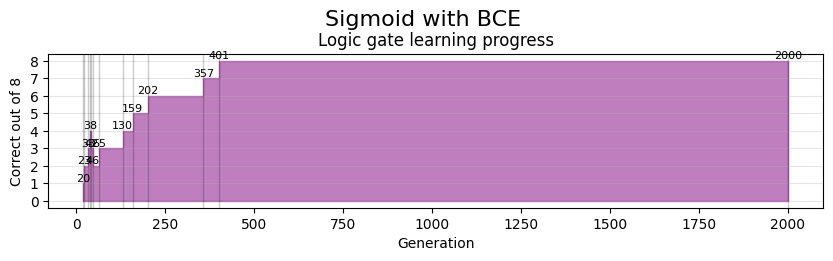

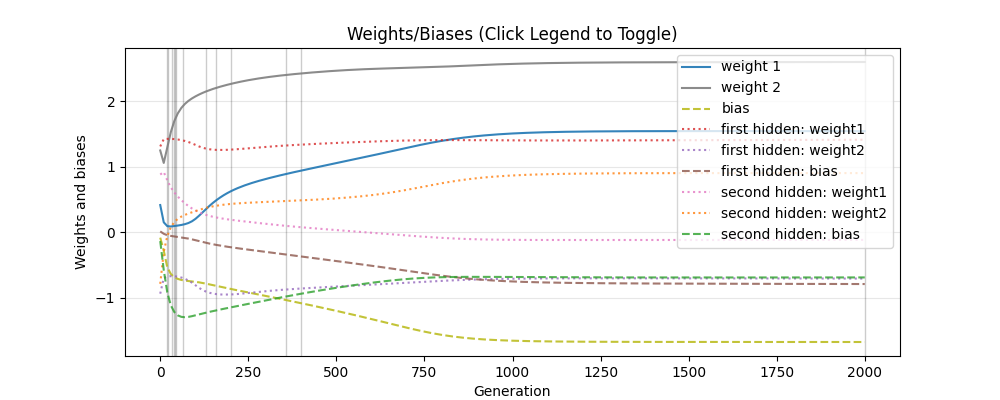

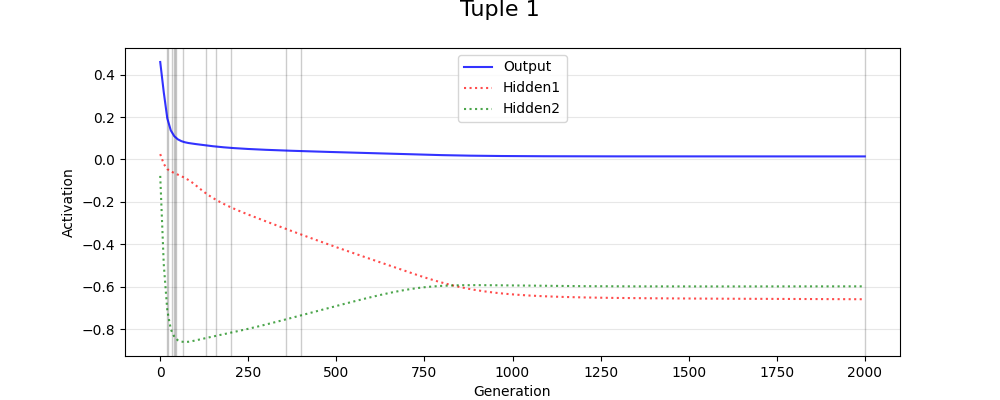

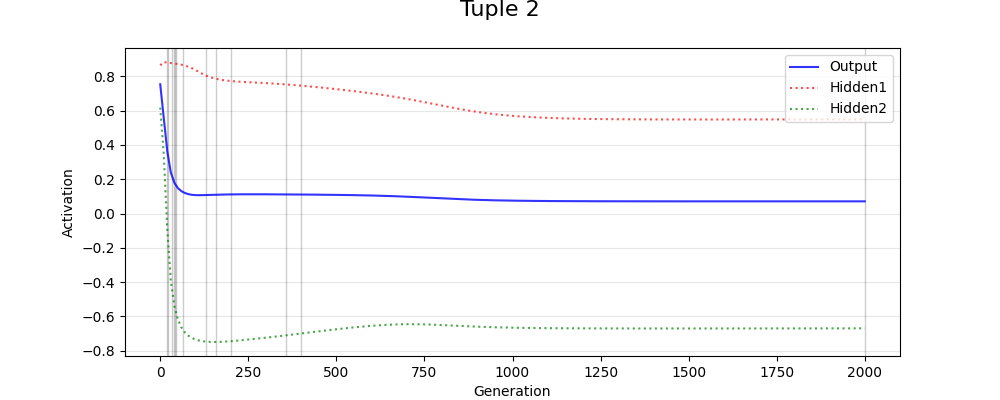

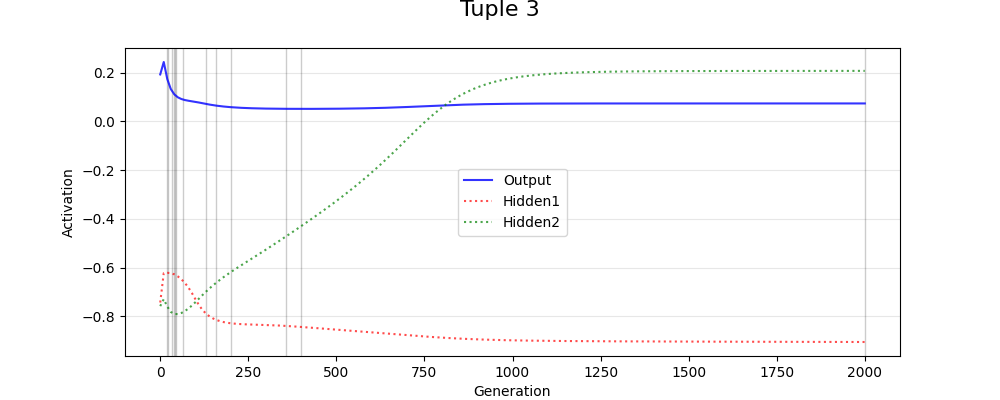

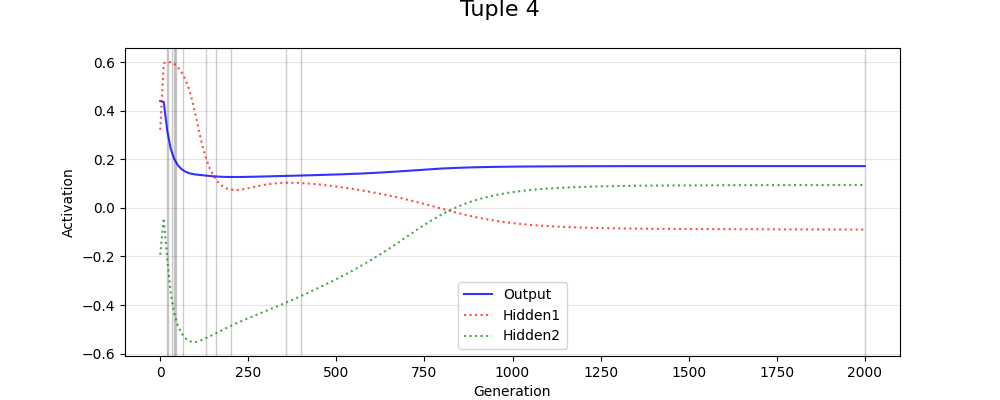

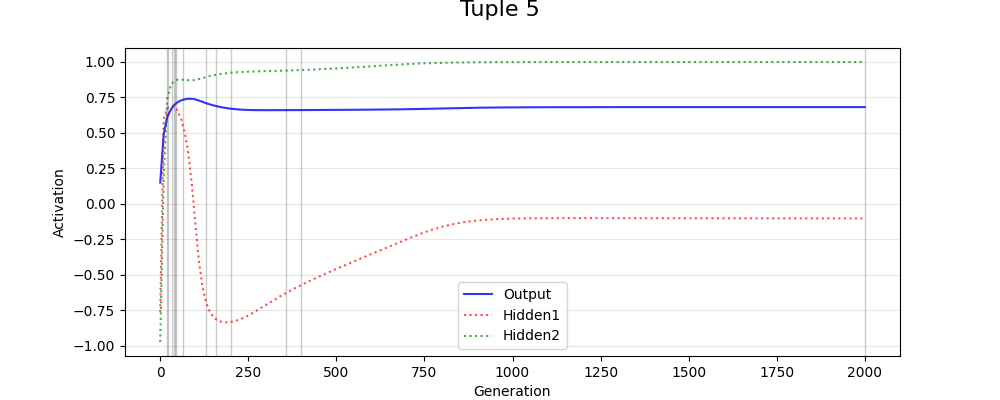

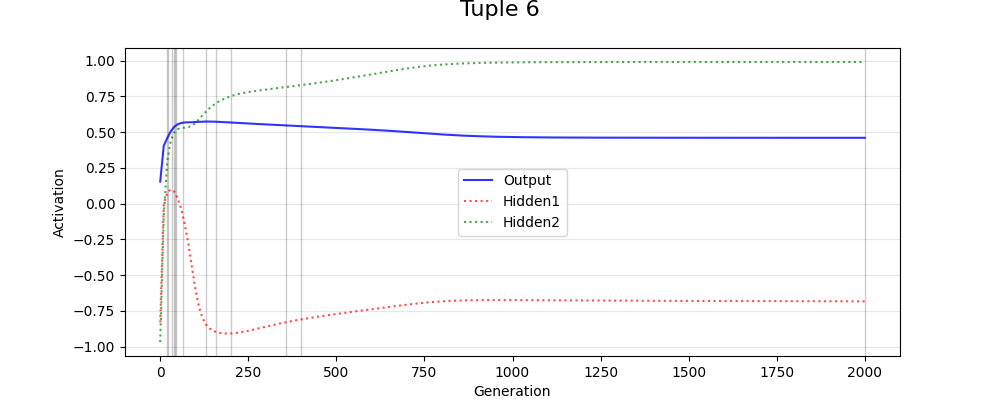

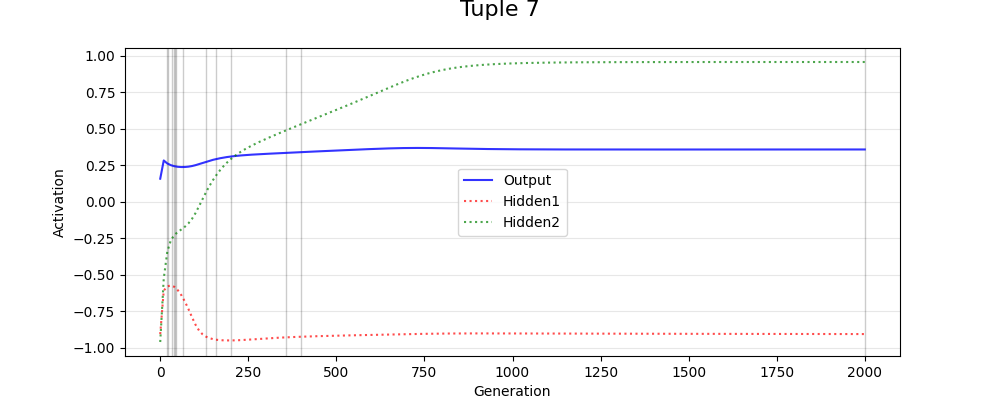

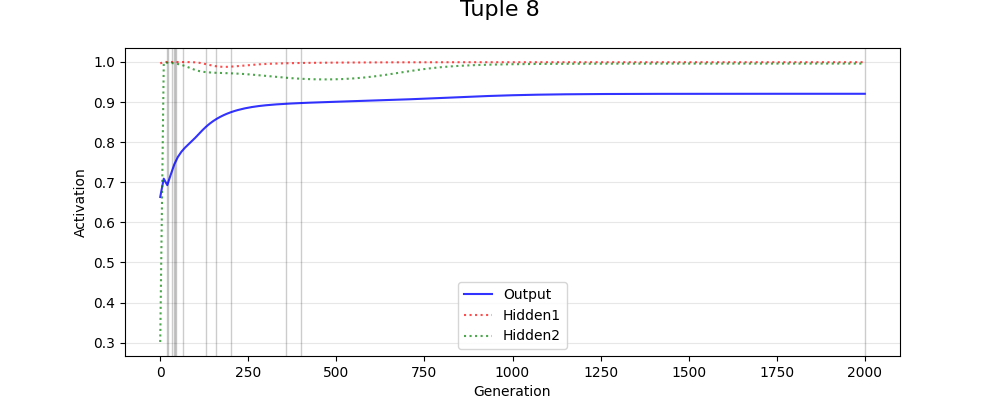

In [165]:
#PLOTTING

import mplcursors
mplcursors.cursor(hover=True)
plt.close('all')
%matplotlib inline 
gen = [gen[0] for gen in finals]
scores = [score[1] for score in finals]

plt.figure(figsize=(10, 2))
plt.suptitle(title, y=1.1, fontsize=16)
for g, s in finals:
    plt.axvline(g, color="black", alpha=0.2, linewidth=1)

    plt.text(
        g,
        s,
        str(g),
        ha="center",
        va="bottom",
        fontsize=8,
    )

plt.fill_between(
    gen,
    scores,
    step="post",
    alpha=0.5,
    color="purple"
)


plt.yticks(range(len(data) + 1))
plt.xlabel("Generation")
plt.ylabel(f'Correct out of {len(data)}')
plt.title("Logic gate learning progress")

plt.grid(True, axis="y", alpha=0.3)
plt.show()
%matplotlib widget

#______________________________________________________
# Weights and biases
fig, ax = plt.subplots(figsize=(10, 4))

for g in finals:
    plt.axvline(g[0], color="black", alpha=0.2, linewidth=1)
    
ax.set_title("Weights/Biases (Click Legend to Toggle)")

# Plot all lines, capturing the returned Line2D objects
line1, = ax.plot(gens, w1s, color="tab:blue", alpha=0.9, label="weight 1")
line2, = ax.plot(gens, w2s, color="tab:gray", alpha=0.9, label="weight 2")
line3, = ax.plot(gens, bs, linestyle="--", color="tab:olive", alpha=0.9, label="bias")
line4, = ax.plot(gens, h1_w1s, linestyle=":", color="tab:red", alpha=0.8, label="first hidden: weight1")
line5, = ax.plot(gens, h1_w2s, linestyle=":", color="tab:purple", alpha=0.8, label="first hidden: weight2")
line6, = ax.plot(gens, h1_bs, linestyle="--", color="tab:brown", alpha=0.8, label="first hidden: bias")
line7, = ax.plot(gens, h2_w1s, linestyle=":", color="tab:pink", alpha=0.8, label="second hidden: weight1")
line8, = ax.plot(gens, h2_w2s, linestyle=":", color="tab:orange", alpha=0.8, label="second hidden: weight2")
line9, = ax.plot(gens, h2_bs, linestyle="--", color="tab:green", alpha=0.8, label="second hidden: bias")

# Add standard plot elements using the 'ax' object methods
ax.set_xlabel("Generation")
ax.set_ylabel("Weights and biases")
ax.grid(True, axis="y", alpha=0.3)

mplcursors.cursor(hover=True)

# 1. Get the legend object
legend = ax.legend(loc='best')

# 2. Create a dictionary mapping legend lines to the actual plotted lines
#    We store the line objects in a list first to easily iterate them
lines = [line1, line2, line3, line4, line5, line6, line7, line8, line9]
line_to_legend = {}
for legline, origline in zip(legend.get_lines(), lines):
    legline.set_picker(5)  # Enable picking with a 5pt tolerance
    line_to_legend[legline] = origline

# 3. Define the callback function that handles the toggle logic
def on_pick(event):
    # The event.artist is the legend line that was clicked
    legend_line = event.artist
    # Get the corresponding actual plot line from our dictionary
    ax_line = line_to_legend[legend_line]
    
    # Toggle visibility
    visible = ax_line.get_visible()
    ax_line.set_visible(not visible)
    
    # Optional: Change the legend line's transparency to show it's "off"
    if visible:
        legend_line.set_alpha(0.5)
    else:
        legend_line.set_alpha(1.0)
    
    # Redraw the figure canvas to apply changes
    fig.canvas.draw()

# 4. Connect the pick event to the figure canvas
# This is what makes the interaction work in the notebook output
fig.canvas.mpl_connect('pick_event', on_pick)

# Use plt.show() as normal to render the interactive figure in the notebook cell
#plt.show()


for i in range(len(data)):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'Tuple {i + 1}', y=1, fontsize=16)
    for g in finals:
        plt.axvline(g[0], color="black", alpha=0.2, linewidth=1)

    plt.plot(gens, [out[i] for out in outs], color="blue", alpha=0.8, label="Output")
    plt.plot(gens, [h1[i] for h1 in h1s], linestyle=":", color="red", alpha=0.7, label="Hidden1")
    plt.plot(gens, [h2[i] for h2 in h2s], linestyle=":",color="green", alpha=0.7, label="Hidden2")
    plt.xlabel("Generation")
    plt.ylabel("Activation")

    plt.grid(True, axis="y", alpha=0.3)
    plt.legend()




# control

Used to test the network against the control dataset. Doesn't work with Sigmoid currently.

In [166]:
final = 0

for x0, x1, y in control:
        *_, h1, h2, prediction = network(x0, x1)
        final += 1 if pred_type(prediction) == y else 0
        print("\033[1;4;41mNEXT ROUND\033[0m\n")
        print(f'\033[1;4mInputs: {x0}, {x1}, correct prediction: {y}, given prediction: {pred_type(prediction)} ({prediction:.8f})\033[0m')
        print("CORRECT!") if pred_type(prediction) == y else print("WRONG!")
        print(f'\033[1;4mHidden1 prediction: {h1:.8f}, Hidden2 prediction: {h2:.8f} \033[0m\n')
        print(f'\033[1mOutput error: {er:.2f}, w1: {w1:.2f}, w2: {w2:.2f}, b: {b:.2f}\033[0m')
        print(f'\033[1mHidden1\033[0m error: {er_h1:.2f}, w1: {h1_w1:.2f}, w2: {h1_w2:.2f}, b: {h1_b:.2f}')
        print(f'\033[1mHidden2\033[0m error: {er_h2:.2f}, w1: {h2_w1:.2f}, w2: {h2_w2:.2f}, b: {h2_b:.2f} \n')
print(final, 'of', len(control))

NEXT ROUND

Inputs: 2, 2, correct prediction: 4, given prediction: 1 (0.72950593)
WRONG!
Hidden1 prediction: 0.54535090, Hidden2 prediction: 0.70387274 

Output error: 0.18, w1: 1.54, w2: 2.60, b: -1.68
Hidden1 error: -0.00, w1: 1.41, w2: -0.71, b: -0.79
Hidden2 error: -0.00, w1: -0.12, w2: 0.90, b: -0.69 

NEXT ROUND

Inputs: 4, 4, correct prediction: 8, given prediction: 1 (0.91445961)
WRONG!
Hidden1 prediction: 0.96511262, Hidden2 prediction: 0.98495143 

Output error: 0.18, w1: 1.54, w2: 2.60, b: -1.68
Hidden1 error: -0.00, w1: 1.41, w2: -0.71, b: -0.79
Hidden2 error: -0.00, w1: -0.12, w2: 0.90, b: -0.69 

NEXT ROUND

Inputs: 6, 6, correct prediction: 12, given prediction: 1 (0.92108639)
WRONG!
Hidden1 prediction: 0.99785968, Hidden2 prediction: 0.99933880 

Output error: 0.18, w1: 1.54, w2: 2.60, b: -1.68
Hidden1 error: -0.00, w1: 1.41, w2: -0.71, b: -0.79
Hidden2 error: -0.00, w1: -0.12, w2: 0.90, b: -0.69 

0 of 3
